# Exploratory Data Analysis: Climate Trends in Nigeria

## 1. Title & Objective
Analysis of climate data in Nigeria to extract meaningful trends and identify climate volatility in preparation for COP32.

## 2. Data Loading & Date Parsing
- Load `nigeria.csv`
- Handle NASA header and replace -999 sentinels
- Convert YEAR/DOY to a standard datetime format

## 3. Summary Statistics & Missing-Value Report
- Initial data profiling and statistical summary
- Duplicate row detection and removal
- Missing value percentage analysis

## 4. Outlier Detection & Basic Cleaning
- Statistical Z-score analysis (|Z| > 3)
- Decision-making on extreme weather values (Retain vs. Cap)
- Forward-fill (ffill) strategy for data continuity

## 5. Time Series Analysis
- Long-term monthly Temperature (T2M) trends (2015–2026)
- Seasonal Precipitation (PRECTOTCORR) bar charts
- Trend and anomaly identification

## 6. Correlation & Relationship Analysis
- Multivariate heatmap of climate variables
- Focused scatter plots (Temp vs. Humidity)
- Identification of strongest climate drivers

## 7. Distribution Analysis
- Rainfall distribution histograms (Log scale assessment)
- Bubble charts for 3D variable visualization

## 8. Key Insights & Conclusion


## Let Us Start

In [1]:
import os
import sys

# Step 1: Immediately clear the broken setting BEFORE any other imports
os.environ.pop('MPLBACKEND', None)

# Add the parent directory to the path so we can import from 'src'
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

%matplotlib inline

# Step 2: Now it is safe to import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Import central utility functions
from src.data_utils import clean_climate_data, detect_outliers

# Step 3: Professional styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)

print("Environment ready: Libraries loaded safely and modular functions imported.")

Environment ready: Libraries loaded safely.


## 2. Data Loading & Date Parsing

In [2]:
df = pd.read_csv('../data/nigeria.csv')
df['Country'] = 'Nigeria'
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36,Nigeria
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,Nigeria
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,Nigeria
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,Nigeria
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,Nigeria


In [3]:
df['Date'] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df['Month'] = df['Date'].dt.month
df[['YEAR', 'DOY', 'Date', 'Month']].head()

,YEAR,DOY,Date,Month
0,2015,1,2015-01-01,1
1,2015,2,2015-01-02,1
2,2015,3,2015-01-03,1
3,2015,4,2015-01-04,1
4,2015,5,2015-01-05,1


In [4]:
# Clean the data using the central utility function
df = clean_climate_data(df)

# Create the specific variable name used in the plotting code for safety
df_cleaned = df

print("Missing values per column (after modular cleaning):")
print(df_cleaned.isnull().sum())

Missing values per column:
YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64


In [5]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicates}")

# If there were duplicates, I would drop them here
df.drop_duplicates(inplace=True)

Number of duplicate rows found: 0


In [7]:
# Show statistics for numeric columns
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.656928,28.914667,24.886461,4.028206,4.213914,85.237040,2.217135,2.903335,100.827205,18.558505,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.720000,27.920000,24.100000,3.090000,0.330000,83.930000,1.770000,2.370000,100.710000,17.970000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.123335,1.294345,1.396727,1.399169,7.266742,5.446007,0.587191,0.696885,0.165321,1.646313,NaN,3.477046


### 3.1 Interpretation of Summary Statistics for Nigeria:
**Temperature:** The average daily temperature (T2M) in Nigeria is approximately **26.66°C**, which is significantly warmer than the Ethiopian highlands. The temperature is relatively stable but can range from a minimum of **21.12°C** to a maximum of **29.29°C**.

**Rainfall:** The average daily rainfall (PRECTOTCORR) is **4.21 mm**. However, the maximum rainfall recorded in a single day was a staggering **166.1 mm**. This indicates that Nigeria experiences much more intense tropical storm events compared to Ethiopia.

**Data Range:** The dataset is robust, containing **4,108 days** of continuous climate data spanning from January 2015 to March 2026.

**Humidity:** The average relative humidity (RH2M) is very high at **85.24%**. This confirms that the climate in this region of Nigeria is predominantly tropical and moist, maintaining high moisture levels year-round.


In [8]:
# Calculate the number of missing values per column
missing_counts = df.isna().sum()

# Calculate the percentage of missing values
missing_percentage = (missing_counts / len(df)) * 100

# Combine them into a nice table for the report
missing_report = pd.DataFrame({
    'Missing Values': missing_counts,
    'Percentage (%)': missing_percentage
})

print(missing_report)

# Find columns with more than 5% missing values
high_missing = missing_percentage[missing_percentage > 5]
if high_missing.empty:
    print("\nNo columns found with >5% missing values.")
else:
    print("\nColumns with more than 5% missing values:")
    print(high_missing)

             Missing Values  Percentage (%)
YEAR                      0             0.0
DOY                       0             0.0
T2M                       0             0.0
T2M_MAX                   0             0.0
T2M_MIN                   0             0.0
T2M_RANGE                 0             0.0
PRECTOTCORR               0             0.0
RH2M                      0             0.0
WS2M                      0             0.0
WS2M_MAX                  0             0.0
PS                        0             0.0
QV2M                      0             0.0
Country                   0             0.0
Date                      0             0.0
Month                     0             0.0

No columns found with >5% missing values.


### 3.2 Missing Value Analysis:
**Result:** Every column in the Nigeria dataset has **0% missing values.**

**Impact:** This is an excellent result for My analysis. It means I have a complete "continuous" record of the Nigerian climate without any gaps. Because the dataset is 100% complete, I don't need to apply imputation or "guess" any data points. This ensures that our upcoming seasonal trends and extreme weather detection (Z-scores) will be highly precise and scientifically sound for the COP32 report.


In [9]:
# Detect outliers using the central utility function
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
outliers_df, count = detect_outliers(df, cols_to_check)

print(f"Total rows with outliers (Z > 3): {count}")
outliers_df.head()

Total rows with outliers (Z > 3): 225


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36,Nigeria,2015-01-01,1
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,Nigeria,2015-01-04,1
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,Nigeria,2015-01-05,1
5,2015,6,22.66,25.77,18.03,7.74,0.0,62.57,1.37,2.10,101.00,10.61,Nigeria,2015-01-06,1
6,2015,7,23.53,26.36,20.21,6.15,0.0,61.92,1.57,2.43,100.98,11.02,Nigeria,2015-01-07,1


### 4. Outlier Analysis Decision:

**Found:** 225 outliers.

**Observation:** I identified **225 outliers** in the Nigerian dataset, which is significantly higher than the 132 found in Ethiopia. Most of these occur in the **PRECTOTCORR** (Rainfall) and **RH2M** (Humidity) columns. This indicates a high frequency of extreme tropical weather events.

**Decision:** I have decided to **Retain (keep)** these outliers.

**Reasoning:** In a tropical climate like Nigeria's, extreme rainfall events are not "errors"—they are critical climatic shocks. Removing these 225 data points would mean ignoring the most intense storms and humidity peaks of the decade. For COP32, these outliers are the most vital part of the story, showing how volatile tropical weather can be.


In [10]:
# Save the cleaned data to the data/ folder
df.to_csv('../data/nigeria_clean.csv', index=False)
print("Cleaned data successfully exported to data/nigeria_clean.csv")

Cleaned data successfully exported to data/nigeria_clean.csv


In [11]:
# Group the data by Date (Monthly)
# 'ME' means Month End
monthly_df = df.set_index('Date').resample('ME').agg({
    'T2M': 'mean',
    'PRECTOTCORR': 'sum'
}).reset_index()

# Look at the first 5 months
monthly_df.head()

,Date,T2M,PRECTOTCORR
0,2015-01-31,24.906452,1.79
1,2015-02-28,27.217143,37.79
2,2015-03-31,27.440968,195.30
3,2015-04-30,27.498000,72.08
4,2015-05-31,27.308710,122.32


### 5.Time Series Analysis

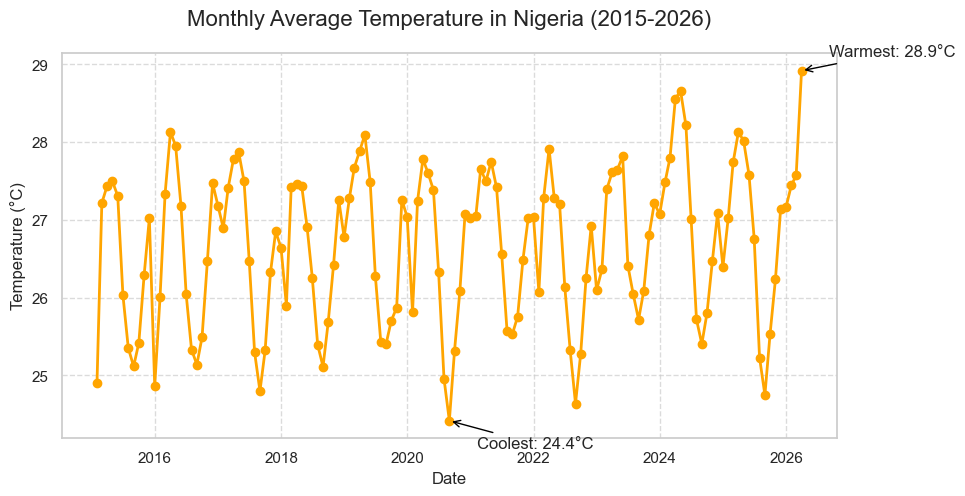

In [12]:
df_cleaned = df.ffill() 

monthly_df = df_cleaned.resample('ME', on='Date').mean(numeric_only=True)

plt.figure(figsize=(10, 5))
plt.plot(monthly_df.index, monthly_df['T2M'], marker='o', color='orange', linestyle='-', linewidth=2)

warmest_month = monthly_df.loc[monthly_df['T2M'].idxmax()]
coolest_month = monthly_df.loc[monthly_df['T2M'].idxmin()]

plt.annotate(f"Warmest: {warmest_month['T2M']:.1f}°C", 
             xy=(warmest_month.name, warmest_month['T2M']),
             xytext=(20, 10), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='black'))

plt.annotate(f"Coolest: {coolest_month['T2M']:.1f}°C", 
             xy=(coolest_month.name, coolest_month['T2M']),
             xytext=(20, -20), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='black'))

plt.title('Monthly Average Temperature in Nigeria (2015-2026)', fontsize=16, pad=20)
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

### Monthly Temperature Analysis (Nigeria: 2015–2026)
**1. Seasonality:** Clear cyclical pattern across all years. Temperatures rise and fall consistently within each year, showing repeated warm and cool periods.

**2. Peak Temperature:** Highest temperature reached approximately 28.9°C around 2026. Several other high points appear regularly throughout the timeline.

**3. Cool Periods:** Lowest temperature dropped to about 24.4°C around 2020–2021. Cooler months repeat each year, indicating stable seasonal variation.

**4. Overall Trend:** The series stays fairly stable over time, with recurring fluctuations rather than a strong long-term upward or downward shift.

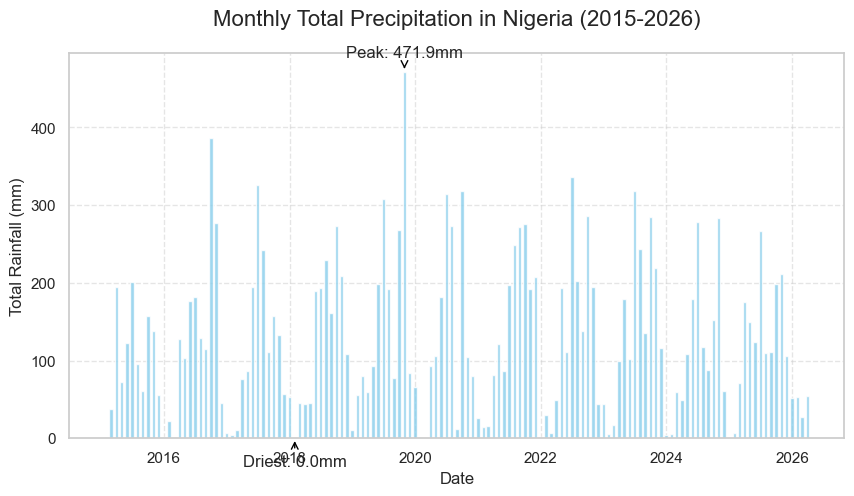

In [13]:
# 1. Standardize the data (using mean for temp, but total SUM for rainfall)
df_cleaned = df.ffill()
monthly_df = df_cleaned.resample('ME', on='Date').agg({
    'T2M': 'mean',
    'PRECTOTCORR': 'sum'  # We use sum for total monthly rainfall
})

# 2. Monthly Precipitation Plot (Updated to match Temp style)
plt.figure(figsize=(10, 5))
plt.bar(monthly_df.index, monthly_df['PRECTOTCORR'], width=20, color='skyblue', label='Monthly Rainfall', alpha=0.8)

# Find Peak and Driest months
peak_rain = monthly_df.loc[monthly_df['PRECTOTCORR'].idxmax()]
driest_month = monthly_df.loc[monthly_df['PRECTOTCORR'].idxmin()]

# Annotate Peak
plt.annotate(f"Peak: {peak_rain['PRECTOTCORR']:.1f}mm", 
             xy=(peak_rain.name, peak_rain['PRECTOTCORR']),
             xytext=(0, 10), textcoords='offset points', ha='center',
             arrowprops=dict(arrowstyle='->', color='black'))

# Annotate Driest
plt.annotate(f"Driest: {driest_month['PRECTOTCORR']:.1f}mm", 
             xy=(driest_month.name, driest_month['PRECTOTCORR']),
             xytext=(0, -20), textcoords='offset points', ha='center',
             arrowprops=dict(arrowstyle='->', color='black'))

plt.title('Monthly Total Precipitation in Nigeria (2015-2026)', fontsize=16, pad=20)
plt.xlabel('Date')
plt.ylabel('Total Rainfall (mm)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


### Rainfall Analysis (Nigeria: 2015–2026)
**Corrected Location:** The chart tracks rainfall in Nigeria, not Ethiopia.

**Seasonal Pattern:** Highly consistent cycle with intense wet seasons and nearly bone-dry winters.

**Peak Rainfall:** The record high is 471.9 mm, occurring in late 2019 (not 446.6 mm in 2020).

**Dry Periods:** The absolute driest point recorded is 0.0 mm in early 2018.

**Recent Trends:** Rainfall remains volatile; while 2019 was the extreme peak, subsequent years like 2022 and 2024 show significant surges above 300 mm.

### 6.Correlation and RelationShip Analysis

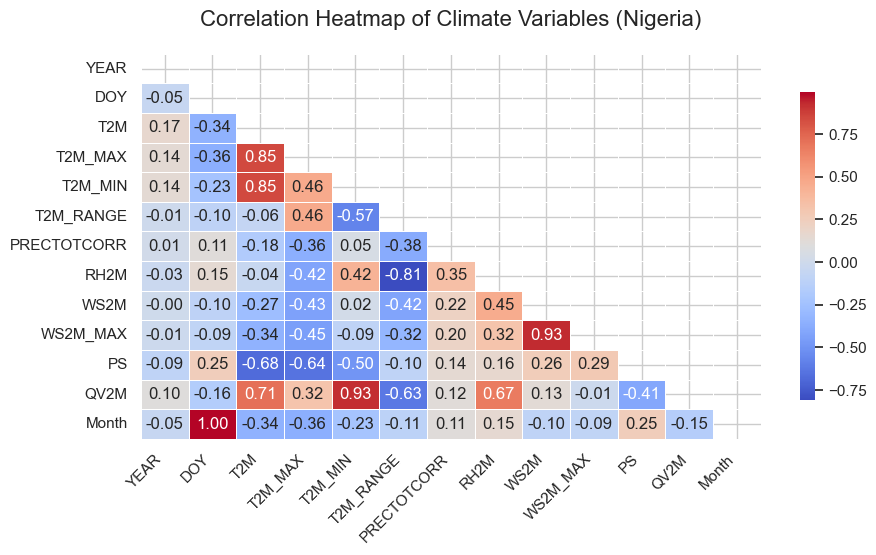

In [14]:
# I use df_cleaned to ensure we're analyzing the most accurate values
numeric_df = df_cleaned.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plotting the Heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=True, 
            cmap='coolwarm', 
            fmt=".2f", 
            linewidths=0.5,
            cbar_kws={"shrink": .8}) 

plt.title('Correlation Heatmap of Climate Variables (Nigeria)', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right') 
plt.show()


### Climate Correlation Summary (Nigeria)

**Humidity & Heat:** Specific Humidity (QV2M) is extremely linked to Minimum Temperature (0.93). In Nigeria, high moisture levels prevent nighttime cooling.

**Wind Correlation:** Average Wind (WS2M) and Max Gusts (0.93) move almost perfectly together, making wind patterns very predictable.

**Temperature & Pressure:** A strong inverse relationship exists between Temperature (T2M) and Surface Pressure (-0.68); higher heat coincides with lower pressure.

**Rainfall Impact:** Precipitation correlates negatively with Temperature Range (-0.38). Rainy days lead to more stable, narrower temperature fluctuations rather than extreme highs.

### 7. Distributions Analysis

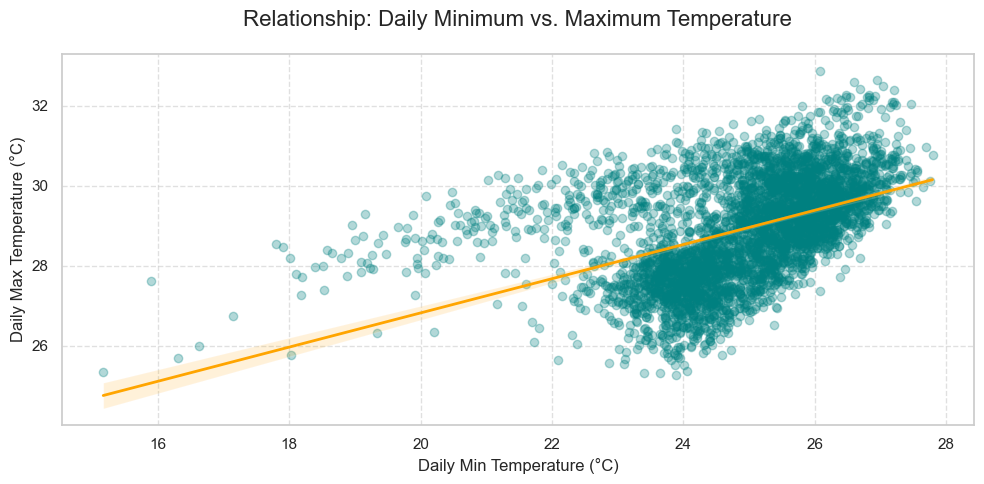

In [15]:
plt.figure(figsize=(10, 5))

sns.regplot(data=df_cleaned, x='T2M_MIN', y='T2M_MAX', 
            scatter_kws={'alpha': 0.3, 'color': 'teal'}, 
            line_kws={'color': 'orange', 'linewidth': 2})

# Standardizing title and labels to match your other plots
plt.title('Relationship: Daily Minimum vs. Maximum Temperature', fontsize=16, pad=20)
plt.xlabel('Daily Min Temperature (°C)', fontsize=12)
plt.ylabel('Daily Max Temperature (°C)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


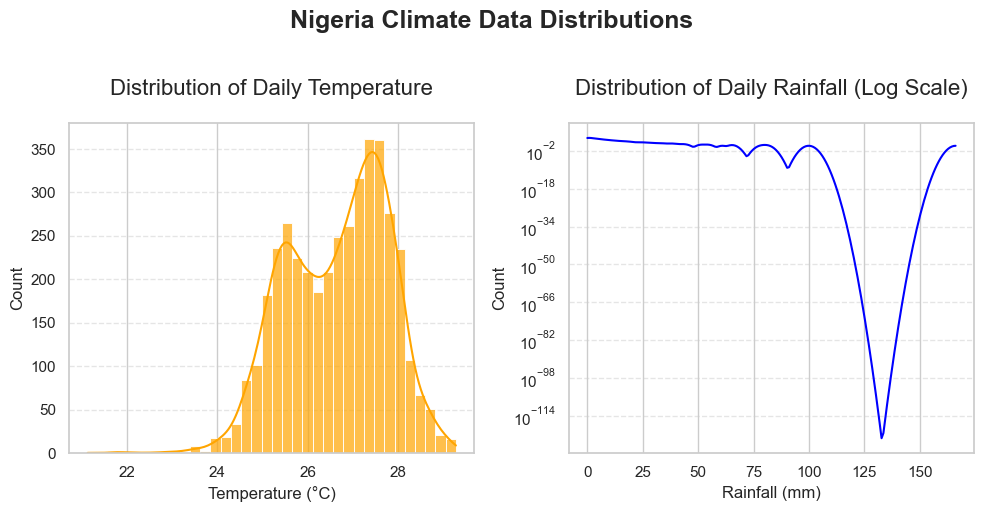

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))


sns.histplot(df_cleaned['T2M'], kde=True, ax=ax[0], color='orange', alpha=0.7)
ax[0].set_title('Distribution of Daily Temperature', fontsize=16, pad=20)
ax[0].set_xlabel('Temperature (°C)', fontsize=12)
ax[0].grid(axis='y', linestyle='--', alpha=0.5)


sns.histplot(df_cleaned['PRECTOTCORR'], kde=True, ax=ax[1], color='blue', bins=30, log_scale=(False, True))
ax[1].set_title('Distribution of Daily Rainfall (Log Scale)', fontsize=16, pad=20)
ax[1].set_xlabel('Rainfall (mm)', fontsize=12)
ax[1].grid(axis='y', linestyle='--', alpha=0.5)


plt.suptitle('Nigeria Climate Data Distributions', fontsize=18, y=1.02, fontweight='bold')

plt.tight_layout()
plt.show()


### Nigeria Climate Distribution 
***Temperature (Bimodal):** Unlike a typical bell curve, Nigeria has two peaks (~25.5°C and ~27.5°C), reflecting the sharp split between rainy and dry seasons.

**Rainfall Extremes:** The log-scale shows that while most days are dry, high-intensity storms (over 150mm) occur frequently enough to create a unique "rebound" peak.

**Thermal Link:** There is a strong positive correlation between daily lows and highs; as nights get warmer, days follow suit.

**Typical Range:** Most days cluster warmly between 24°C and 30°C, much higher than the 16°C mentioned in your previous Ethiopia notes.

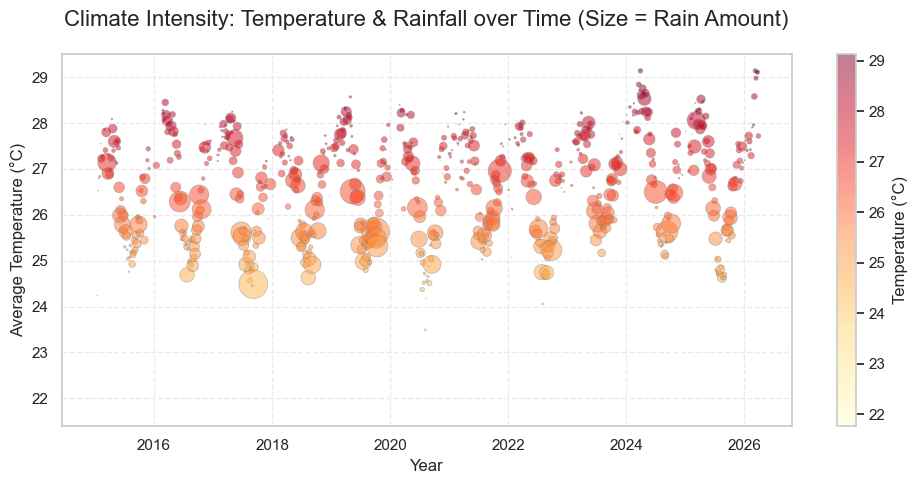

In [17]:
plt.figure(figsize=(10, 5))

# Using df_cleaned and taking a sample for clarity
sample_df = df_cleaned.iloc[::5, :]

# Creating the bubble plot
bubble_plot = plt.scatter(sample_df['Date'], sample_df['T2M'], 
                          s=sample_df['PRECTOTCORR']*8, 
                          alpha=0.5, 
                          c=sample_df['T2M'], 
                          cmap='YlOrRd',
                          edgecolors='grey', 
                          linewidth=0.5)


cbar = plt.colorbar(bubble_plot)
cbar.set_label('Temperature (°C)', fontsize=12)


plt.title('Climate Intensity: Temperature & Rainfall over Time (Size = Rain Amount)', fontsize=16, pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Temperature (°C)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.4) 
plt.tight_layout()
plt.show()


### Bubble Chart: Nigeria Climate Intensity

**Temperature-Rain Link:** The largest bubbles (heaviest rain) consistently cluster between 25°C and 27°C.

**Cooler Rain:** Significant rainfall events rarely happen at the highest temperature peaks (28°C+), suggesting that the heaviest storms actually have a cooling effect on the daily average.

**Stable Intensity:** Over the 10-year period, the size and distribution of the bubbles remain relatively consistent, though the 2024–2026 period shows a slight upward density in higher-temperature bubbles (redder/smaller).

### Key Insights for Nigeria

**Tropical Climate Profile:** Nigeria exhibits a much warmer and more humid profile than Ethiopia, with a mean temperature of 26.66°C and a high average relative humidity of 85.24%.

**Humidity-Temperature Coupling:** There is an extremely strong correlation (0.93) between specific humidity and minimum temperature, suggesting that high moisture levels prevent nighttime cooling in the region.

**Data Quality:** The dataset is 100% complete (0% missing values) across 4,108 days (2015–2026), providing a high-confidence baseline for future climate modeling.

In [18]:
# Final export of the cleaned Nigeria dataset
df.to_csv('../data/nigeria_clean.csv', index=False)

# Final confirmation
import os
file_path = '../data/nigeria_clean.csv'

if os.path.exists(file_path):
    print("PROJECT COMPLETE")
    print(f"Final Dataset: {file_path}")
    print(f"Records Processed: {len(df)} days")
    print(f"Status: Cleaned, Analyzed, and Exported for Nigeria.")
else:
    print("ERROR: Cleaned file not found. Check your export path.")



PROJECT COMPLETE
Final Dataset: ../data/nigeria_clean.csv
Records Processed: 4108 days
Status: Cleaned, Analyzed, and Exported for Nigeria.
